# NFL Game Prediction — Modeling

This notebook trains and evaluates machine learning models for predicting the probability that the home team wins an NFL game.

The models use pre-game features created in the previous notebook:

- `win_pct_diff`
- `ppg_diff`
- `defense_diff`

The data is split chronologically to prevent future games from influencing predictions about earlier games.

The initial models are:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

The primary evaluation metrics are **Log Loss** and **Brier Score**, since the goal of this project is to produce reliable win probabilities rather than only predicting the winning team.

## 1. Imports

In [143]:
import polars as pl
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

## 2. Load the Feature-Engineered Dataset

The feature engineering notebook saved the processed dataset as a Parquet file.

This dataset contains only information that was available before each game.

In [144]:
model_data = pl.read_parquet(
    "../data/processed/model_data.parquet"
)

print(model_data.shape)

(2895, 110)


In [145]:
model_data.head()

game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,…,home_rolling_rush_epa_5,away_off_epa,away_def_epa,away_rolling_off_epa_5,away_rolling_def_epa_5,away_rolling_pass_epa_5,away_rolling_rush_epa_5,off_epa_diff,def_epa_diff,rolling_off_epa_diff_5,rolling_def_epa_diff_5,rolling_pass_epa_diff_5,rolling_rush_epa_diff_5,home_qb_epa,home_qb_completion,home_qb_td_rate,home_qb_int_rate,home_qb_rolling_epa_5,home_qb_rolling_completion_5,home_qb_rolling_td_rate_5,home_qb_rolling_int_rate_5,away_qb_epa,away_qb_completion,away_qb_td_rate,away_qb_int_rate,away_qb_rolling_epa_5,away_qb_rolling_completion_5,away_qb_rolling_td_rate_5,away_qb_rolling_int_rate_5,qb_epa_diff,qb_completion_diff,qb_td_rate_diff,qb_int_rate_diff,qb_rolling_epa_diff_5,qb_rolling_completion_diff_5,qb_rolling_td_rate_diff_5,qb_rolling_int_rate_diff_5
str,i32,str,i32,str,str,str,str,i32,str,i32,str,i32,i32,i32,str,i32,str,str,i32,str,i32,i32,i32,i32,i32,f64,i32,i32,f64,i32,i32,i32,str,str,i32,i32,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2015_01_PIT_NE""",2015,"""REG""",1,"""2015-09-10""","""Thursday""","""20:30""","""PIT""",21,"""NE""",28,"""Home""",7,49,0,"""2015091000""",56503,null,"""201509100nwe""",3406,"""400791485""",null,7,7,305,-350,7.5,-111,101,51.0,-107,-103,0,"""outdoors""","""fieldturf""",65,7,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_IND_BUF""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""IND""",14,"""BUF""",27,"""Home""",13,41,0,"""2015091304""",56504,null,"""201509130buf""",3413,"""400791541""",null,7,7,-109,-101,-1.0,-103,-107,44.5,102,-113,0,"""outdoors""","""a_turf""",56,15,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_GB_CHI""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""GB""",31,"""CHI""",23,"""Home""",-8,54,0,"""2015091300""",56505,null,"""201509130chi""",3407,"""400791489""",null,7,7,-250,222,-5.5,-110,100,48.5,-107,-103,1,"""outdoors""","""grass""",72,11,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_KC_HOU""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""KC""",27,"""HOU""",20,"""Home""",-7,47,0,"""2015091306""",56506,null,"""201509130htx""",3409,"""400791493""",null,7,7,-105,-105,-1.0,100,-110,41.0,-103,-107,0,"""closed""","""grass""",null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2015_01_CAR_JAX""",2015,"""REG""",1,"""2015-09-13""","""Sunday""","""13:00""","""CAR""",20,"""JAX""",9,"""Home""",-11,29,0,"""2015091302""",56507,null,"""201509130jax""",3411,"""400791547""",null,7,7,-145,131,-3.0,-100,-110,41.0,-107,-103,0,"""outdoors""","""grass""",77,7,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


## 3. Chronological Train / Validation / Test Split

To avoid data leakage, the model is evaluated chronologically.

- Training: 2015–2022
- Validation: 2023
- Test: 2024–2025

The validation set is used to compare models.

The test set is kept separate until the final evaluation.

In [146]:
train_data = model_data.filter(
    pl.col("season") <= 2022
)

validation_data = model_data.filter(
    pl.col("season") == 2023
)

test_data = model_data.filter(
    pl.col("season") >= 2024
)

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Train: (2079, 110)
Validation: (272, 110)
Test: (544, 110)


## 4. Define Features and Target

The model predicts whether the home team wins.

Features represent the difference between the two teams before the game:

- `win_pct_diff`: difference in previous win percentage
- `ppg_diff`: difference in points scored per game
- `defense_diff`: difference in points allowed per game

The target is:

- `home_win = 1`: home team won
- `home_win = 0`: home team lost

In [175]:
baseline_features = [
    "win_pct_diff",
    "ppg_diff",
    "defense_diff",
]

rolling_features = [
    "rolling_win_pct_diff_5",
    "rolling_ppg_diff_5",
    "rolling_defense_diff_5",
    "rolling_point_diff_diff_5",
]

epa_features = [
    "off_epa_diff",
    "def_epa_diff",
    "rolling_off_epa_diff_5",
    "rolling_def_epa_diff_5",
    "rolling_pass_epa_diff_5",
    "rolling_rush_epa_diff_5",
]

qb_features = [
    "qb_epa_diff",
    "qb_completion_diff",
    "qb_td_rate_diff",
    "qb_int_rate_diff",
    "qb_rolling_epa_diff_5",
    "qb_rolling_completion_diff_5",
    "qb_rolling_td_rate_diff_5",
    "qb_rolling_int_rate_diff_5",
]
v1_features = baseline_features

v2_features = (
    baseline_features
    + rolling_features
)

v3_features = (
    baseline_features
    + rolling_features
    + epa_features
)

v4_features = (
    baseline_features
    + rolling_features
    + epa_features
    + qb_features
)

target = "home_win"

print(f"V4 features: {len(v4_features)}")

V4 features: 21


In [176]:
print("V1:", len(v1_features))
print("V2:", len(v2_features))
print("V3:", len(v3_features))
print("V4:", len(v4_features))

V1: 3
V2: 7
V3: 13
V4: 21


In [149]:
train_v4 = train_data.drop_nulls(subset=v4_features)
validation_v4 = validation_data.drop_nulls(subset=v4_features)
test_v4 = test_data.drop_nulls(subset=v4_features)

print("Train:", train_v4.shape)
print("Validation:", validation_v4.shape)
print("Test:", test_v4.shape)

Train: (1760, 110)
Validation: (245, 110)
Test: (459, 110)


In [177]:
v4_test_ids = (
    test_data
    .drop_nulls(subset=v4_features)
    .select("game_id")
    .unique()
)

In [178]:
test_v1 = (
    test_data
    .join(v4_test_ids, on="game_id", how="inner")
    .drop_nulls(subset=v1_features)
)

test_v2 = (
    test_data
    .join(v4_test_ids, on="game_id", how="inner")
    .drop_nulls(subset=v2_features)
)

test_v3 = (
    test_data
    .join(v4_test_ids, on="game_id", how="inner")
    .drop_nulls(subset=v3_features)
)

test_v4 = (
    test_data
    .join(v4_test_ids, on="game_id", how="inner")
    .drop_nulls(subset=v4_features)
)

In [179]:
train_v1 = train_data.drop_nulls(subset=v1_features)
train_v2 = train_data.drop_nulls(subset=v2_features)
train_v3 = train_data.drop_nulls(subset=v3_features)
train_v4 = train_data.drop_nulls(subset=v4_features)

In [180]:
datasets = {
    "V1": {
        "features": v1_features,
        "train": train_v1,
        "test": test_v1,
    },
    "V2": {
        "features": v2_features,
        "train": train_v2,
        "test": test_v2,
    },
    "V3": {
        "features": v3_features,
        "train": train_v3,
        "test": test_v3,
    },
    "V4": {
        "features": v4_features,
        "train": train_v4,
        "test": test_v4,
    },
}

## 5. Convert Data for Scikit-Learn

Polars is used for data preparation, while scikit-learn receives NumPy arrays for model training.

In [150]:
X_train = train_v3.select(v3_features).to_numpy()
y_train = train_v3.select(target).to_numpy().ravel()

X_validation = validation_v3.select(v3_features).to_numpy()
y_validation = validation_v3.select(target).to_numpy().ravel()

X_test = test_v3.select(v3_features).to_numpy()
y_test = test_v3.select(target).to_numpy().ravel()

In [151]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1834, 13)
y_train: (1834,)
X_val: (272, 7)
y_val: (272,)
X_test: (512, 13)
y_test: (512,)


In [181]:
def create_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=10,
            random_state=42
        ),

        "Gradient Boosting": HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42
        )
    }

In [182]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = model.predict(X_test)

    return {
        "Log Loss": log_loss(y_test, probabilities),
        "Brier Score": brier_score_loss(y_test, probabilities),
        "Accuracy": accuracy_score(y_test, predictions),
    }

In [183]:
results = []

for version, data in datasets.items():

    features = data["features"]
    train = data["train"]
    test = data["test"]

    X_train = train.select(features).to_numpy()
    y_train = train.select(target).to_numpy().ravel()

    X_test = test.select(features).to_numpy()
    y_test = test.select(target).to_numpy().ravel()

    for model_name, model in create_models().items():

        metrics = evaluate_model(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )

        results.append({
            "Version": version,
            "Model": model_name,
            **metrics
        })

In [188]:
results_df.sort([
    "Version",
    "Model"
])

pl.Config.set_tbl_rows(12)

results_df.sort(["Version", "Model"])

Version,Model,Log Loss,Brier Score,Accuracy
str,str,f64,f64,f64
"""V1""","""Gradient Boosting""",0.662809,0.234541,0.594771
"""V1""","""Logistic Regression""",0.647085,0.227528,0.649237
"""V1""","""Random Forest""",0.638404,0.22399,0.64488
"""V2""","""Gradient Boosting""",0.658819,0.233486,0.618736
"""V2""","""Logistic Regression""",0.64167,0.224968,0.653595
"""V2""","""Random Forest""",0.634533,0.222327,0.633987
"""V3""","""Gradient Boosting""",0.669862,0.236708,0.614379
"""V3""","""Logistic Regression""",0.638754,0.22359,0.640523
"""V3""","""Random Forest""",0.634776,0.222523,0.662309


In [192]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

# V2
X_train_v2 = train_v2.select(v2_features).to_numpy()
y_train_v2 = train_v2.select(target).to_numpy().ravel()

X_test_v2 = test_v2.select(v2_features).to_numpy()
y_test_v2 = test_v2.select(target).to_numpy().ravel()

# V3
X_train_v3 = train_v3.select(v3_features).to_numpy()
y_train_v3 = train_v3.select(target).to_numpy().ravel()

X_test_v3 = test_v3.select(v3_features).to_numpy()
y_test_v3 = test_v3.select(target).to_numpy().ravel()


rf_v2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

rf_v3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)


rf_v2.fit(X_train_v2, y_train_v2)
rf_v3.fit(X_train_v3, y_train_v3)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [193]:
rf_v2_probs = rf_v2.predict_proba(X_test_v2)[:, 1]
rf_v2_preds = rf_v2.predict(X_test_v2)

rf_v3_probs = rf_v3.predict_proba(X_test_v3)[:, 1]
rf_v3_preds = rf_v3.predict(X_test_v3)

In [194]:
evaluation_results = [
    {
        "Model": "V2 Random Forest",
        "Log Loss": log_loss(y_test_v2, rf_v2_probs),
        "Brier Score": brier_score_loss(y_test_v2, rf_v2_probs),
        "Accuracy": accuracy_score(y_test_v2, rf_v2_preds),
    },
    {
        "Model": "V3 Random Forest",
        "Log Loss": log_loss(y_test_v3, rf_v3_probs),
        "Brier Score": brier_score_loss(y_test_v3, rf_v3_probs),
        "Accuracy": accuracy_score(y_test_v3, rf_v3_preds),
    }
]

evaluation_df = pl.DataFrame(evaluation_results)

evaluation_df

Model,Log Loss,Brier Score,Accuracy
str,f64,f64,f64
"""V2 Random Forest""",0.634533,0.222327,0.633987
"""V3 Random Forest""",0.634776,0.222523,0.662309


In [195]:
v2_importance = (
    pl.DataFrame({
        "Feature": v2_features,
        "Importance": rf_v2.feature_importances_
    })
    .sort("Importance", descending=True)
)

v2_importance

Feature,Importance
str,f64
"""win_pct_diff""",0.213491
"""ppg_diff""",0.194378
"""rolling_ppg_diff_5""",0.149913
"""rolling_point_diff_diff_5""",0.142112
"""defense_diff""",0.111104
"""rolling_defense_diff_5""",0.098518
"""rolling_win_pct_diff_5""",0.090485


In [196]:
v3_importance = (
    pl.DataFrame({
        "Feature": v3_features,
        "Importance": rf_v3.feature_importances_
    })
    .sort("Importance", descending=True)
)

v3_importance

Feature,Importance
str,f64
"""win_pct_diff""",0.122472
"""off_epa_diff""",0.121429
"""rolling_off_epa_diff_5""",0.107898
"""rolling_point_diff_diff_5""",0.089846
"""ppg_diff""",0.088976
"""rolling_pass_epa_diff_5""",0.085884
…,…
"""rolling_win_pct_diff_5""",0.054673
"""defense_diff""",0.05465


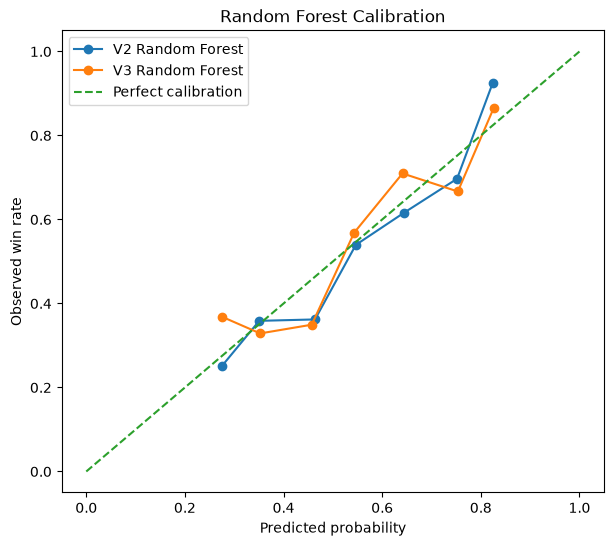

In [197]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true_v2, prob_pred_v2 = calibration_curve(
    y_test_v2,
    rf_v2_probs,
    n_bins=10,
    strategy="uniform"
)

prob_true_v3, prob_pred_v3 = calibration_curve(
    y_test_v3,
    rf_v3_probs,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred_v2,
    prob_true_v2,
    marker="o",
    label="V2 Random Forest"
)

plt.plot(
    prob_pred_v3,
    prob_true_v3,
    marker="o",
    label="V3 Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Predicted probability")
plt.ylabel("Observed win rate")
plt.title("Random Forest Calibration")
plt.legend()

plt.show()

In [198]:
import numpy as np

def calculate_ece(y_true, probabilities, n_bins=10):

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0

    for i in range(n_bins):

        if i == n_bins - 1:
            mask = (
                (probabilities >= bins[i]) &
                (probabilities <= bins[i + 1])
            )
        else:
            mask = (
                (probabilities >= bins[i]) &
                (probabilities < bins[i + 1])
            )

        if mask.sum() == 0:
            continue

        predicted_probability = probabilities[mask].mean()
        observed_frequency = y_true[mask].mean()

        ece += (
            mask.sum() /
            len(y_true)
        ) * abs(
            predicted_probability -
            observed_frequency
        )

    return ece

In [199]:
ece_v2 = calculate_ece(
    y_test_v2,
    rf_v2_probs
)

ece_v3 = calculate_ece(
    y_test_v3,
    rf_v3_probs
)

print(f"V2 ECE: {ece_v2:.4f}")
print(f"V3 ECE: {ece_v3:.4f}")

V2 ECE: 0.0350
V3 ECE: 0.0617


In [200]:
cm_v2 = confusion_matrix(
    y_test_v2,
    rf_v2_preds
)

cm_v3 = confusion_matrix(
    y_test_v3,
    rf_v3_preds
)

print("V2 Random Forest")
print(cm_v2)

print("\nV3 Random Forest")
print(cm_v3)

V2 Random Forest
[[105 111]
 [ 57 186]]

V3 Random Forest
[[128  88]
 [ 67 176]]


In [201]:
print("V2 Random Forest")
print(
    classification_report(
        y_test_v2,
        rf_v2_preds
    )
)

print("V3 Random Forest")
print(
    classification_report(
        y_test_v3,
        rf_v3_preds
    )
)

V2 Random Forest
              precision    recall  f1-score   support

           0       0.65      0.49      0.56       216
           1       0.63      0.77      0.69       243

    accuracy                           0.63       459
   macro avg       0.64      0.63      0.62       459
weighted avg       0.64      0.63      0.63       459

V3 Random Forest
              precision    recall  f1-score   support

           0       0.66      0.59      0.62       216
           1       0.67      0.72      0.69       243

    accuracy                           0.66       459
   macro avg       0.66      0.66      0.66       459
weighted avg       0.66      0.66      0.66       459



In [202]:
final_evaluation = pl.DataFrame([
    {
        "Model": "V2 Random Forest",
        "Log Loss": log_loss(y_test_v2, rf_v2_probs),
        "Brier Score": brier_score_loss(y_test_v2, rf_v2_probs),
        "Accuracy": accuracy_score(y_test_v2, rf_v2_preds),
        "ECE": ece_v2
    },
    {
        "Model": "V3 Random Forest",
        "Log Loss": log_loss(y_test_v3, rf_v3_probs),
        "Brier Score": brier_score_loss(y_test_v3, rf_v3_probs),
        "Accuracy": accuracy_score(y_test_v3, rf_v3_preds),
        "ECE": ece_v3
    }
])

final_evaluation

Model,Log Loss,Brier Score,Accuracy,ECE
str,f64,f64,f64,f64
"""V2 Random Forest""",0.634533,0.222327,0.633987,0.03502
"""V3 Random Forest""",0.634776,0.222523,0.662309,0.061744


In [203]:
comparison = (
    test_v3
    .select([
        "game_id",
        "season",
        "week",
        "home_team",
        "away_team",
        "home_win"
    ])
    .with_columns([
        pl.Series("v2_probability", rf_v2_probs),
        pl.Series("v3_probability", rf_v3_probs),
        pl.Series("v2_prediction", rf_v2_preds),
        pl.Series("v3_prediction", rf_v3_preds),
    ])
    .with_columns([
        (
            pl.col("v2_probability") - 0.5
        ).abs().alias("v2_confidence"),

        (
            pl.col("v3_probability") - 0.5
        ).abs().alias("v3_confidence"),
    ])
)

In [204]:
comparison.head(20)

game_id,season,week,home_team,away_team,home_win,v2_probability,v3_probability,v2_prediction,v3_prediction,v2_confidence,v3_confidence
str,i32,i32,str,str,i8,f64,f64,i8,i8,f64,f64
"""2024_02_BUF_MIA""",2024,2,"""MIA""","""BUF""",0,0.546602,0.545124,1,1,0.046602,0.045124
"""2024_02_LV_BAL""",2024,2,"""BAL""","""LV""",0,0.62665,0.736212,1,1,0.12665,0.236212
"""2024_02_LAC_CAR""",2024,2,"""CAR""","""LAC""",0,0.420928,0.378277,0,0,0.079072,0.121723
"""2024_02_NO_DAL""",2024,2,"""DAL""","""NO""",0,0.42037,0.429023,0,0,0.07963,0.070977
"""2024_02_TB_DET""",2024,2,"""DET""","""TB""",0,0.519393,0.450957,1,0,0.019393,0.049043
"""2024_02_IND_GB""",2024,2,"""GB""","""IND""",1,0.527825,0.507584,1,1,0.027825,0.007584
…,…,…,…,…,…,…,…,…,…,…,…
"""2024_02_CHI_HOU""",2024,2,"""HOU""","""CHI""",1,0.656332,0.63979,1,1,0.156332,0.13979
"""2024_02_ATL_PHI""",2024,2,"""PHI""","""ATL""",0,0.65502,0.749453,1,1,0.15502,0.249453


In [205]:
disagreements = (
    comparison
    .filter(
        pl.col("v2_prediction") !=
        pl.col("v3_prediction")
    )
    .sort("v3_confidence", descending=True)
)

disagreements

game_id,season,week,home_team,away_team,home_win,v2_probability,v3_probability,v2_prediction,v3_prediction,v2_confidence,v3_confidence
str,i32,i32,str,str,i8,f64,f64,i8,i8,f64,f64
"""2025_07_IND_LAC""",2025,7,"""LAC""","""IND""",0,0.510313,0.420245,1,0,0.010313,0.079755
"""2024_11_GB_CHI""",2024,11,"""CHI""","""GB""",0,0.519302,0.424816,1,0,0.019302,0.075184
"""2024_02_SEA_NE""",2024,2,"""NE""","""SEA""",0,0.478618,0.566231,0,1,0.021382,0.066231
"""2025_13_KC_DAL""",2025,13,"""DAL""","""KC""",1,0.594513,0.434995,1,0,0.094513,0.065005
"""2024_07_BAL_TB""",2024,7,"""TB""","""BAL""",0,0.516733,0.435789,1,0,0.016733,0.064211
"""2024_06_DET_DAL""",2024,6,"""DAL""","""DET""",0,0.511997,0.437192,1,0,0.011997,0.062808
…,…,…,…,…,…,…,…,…,…,…,…
"""2025_12_ATL_NO""",2025,12,"""NO""","""ATL""",0,0.503254,0.495002,1,0,0.003254,0.004998
"""2024_14_CIN_DAL""",2024,14,"""DAL""","""CIN""",0,0.529083,0.495536,1,0,0.029083,0.004464


In [206]:
disagreements = (
    comparison
    .filter(
        pl.col("v2_prediction") != pl.col("v3_prediction")
    )
    .with_columns(
        pl.when(pl.col("v3_prediction") == pl.col("home_win"))
        .then(pl.lit("V3 Correct"))
        .otherwise(pl.lit("V3 Wrong"))
        .alias("v3_result")
    )
)

disagreements

game_id,season,week,home_team,away_team,home_win,v2_probability,v3_probability,v2_prediction,v3_prediction,v2_confidence,v3_confidence,v3_result
str,i32,i32,str,str,i8,f64,f64,i8,i8,f64,f64,str
"""2024_02_TB_DET""",2024,2,"""DET""","""TB""",0,0.519393,0.450957,1,0,0.019393,0.049043,"""V3 Correct"""
"""2024_02_SF_MIN""",2024,2,"""MIN""","""SF""",1,0.534941,0.490392,1,0,0.034941,0.009608,"""V3 Wrong"""
"""2024_02_SEA_NE""",2024,2,"""NE""","""SEA""",0,0.478618,0.566231,0,1,0.021382,0.066231,"""V3 Wrong"""
"""2024_02_NYJ_TEN""",2024,2,"""TEN""","""NYJ""",0,0.536345,0.491653,1,0,0.036345,0.008347,"""V3 Correct"""
"""2024_03_LAC_PIT""",2024,3,"""PIT""","""LAC""",1,0.486438,0.51483,0,1,0.013562,0.01483,"""V3 Correct"""
"""2024_03_WAS_CIN""",2024,3,"""CIN""","""WAS""",0,0.521357,0.478452,1,0,0.021357,0.021548,"""V3 Correct"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2025_15_GB_DEN""",2025,15,"""DEN""","""GB""",1,0.56016,0.465413,1,0,0.06016,0.034587,"""V3 Wrong"""
"""2025_16_GB_CHI""",2025,16,"""CHI""","""GB""",1,0.577856,0.453795,1,0,0.077856,0.046205,"""V3 Wrong"""


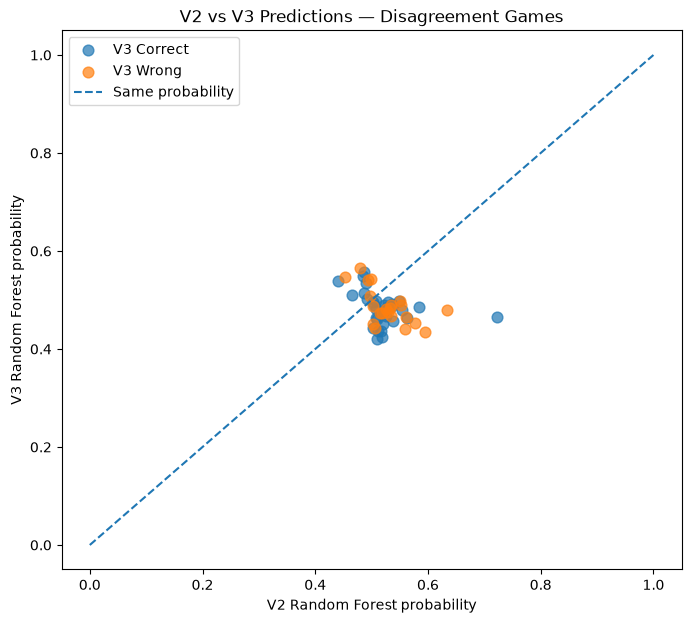

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

for result in ["V3 Correct", "V3 Wrong"]:

    subset = disagreements.filter(
        pl.col("v3_result") == result
    )

    plt.scatter(
        subset["v2_probability"].to_list(),
        subset["v3_probability"].to_list(),
        label=result,
        alpha=0.7,
        s=60
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Same probability"
)

plt.xlabel("V2 Random Forest probability")
plt.ylabel("V3 Random Forest probability")
plt.title("V2 vs V3 Predictions — Disagreement Games")
plt.legend()

plt.show()

In [209]:
disagreements = disagreements.with_columns(
    (
        pl.col("v3_probability") -
        pl.col("v2_probability")
    ).alias("probability_change")
)

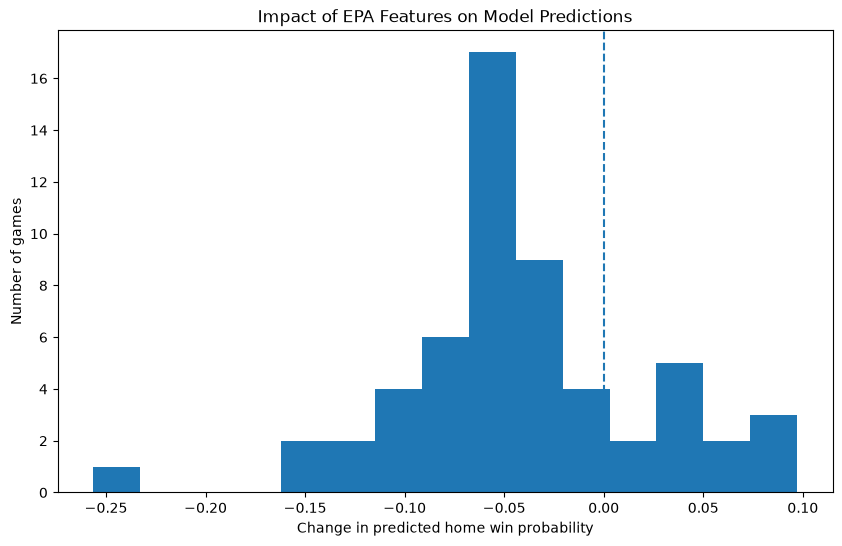

In [210]:
plt.figure(figsize=(10, 6))

plt.hist(
    disagreements["probability_change"].to_list(),
    bins=15
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Change in predicted home win probability")
plt.ylabel("Number of games")
plt.title("Impact of EPA Features on Model Predictions")

plt.show()

In [211]:
disagreements.sort(
    "probability_change",
    descending=True
).select([
    "game_id",
    "season",
    "week",
    "home_team",
    "away_team",
    "home_win",
    "v2_probability",
    "v3_probability",
    "probability_change",
    "v3_result"
])

game_id,season,week,home_team,away_team,home_win,v2_probability,v3_probability,probability_change,v3_result
str,i32,i32,str,str,i8,f64,f64,f64,str
"""2025_12_IND_KC""",2025,12,"""KC""","""IND""",1,0.440812,0.538088,0.097275,"""V3 Correct"""
"""2024_07_PHI_NYG""",2024,7,"""NYG""","""PHI""",0,0.452368,0.54611,0.093743,"""V3 Wrong"""
"""2024_02_SEA_NE""",2024,2,"""NE""","""SEA""",0,0.478618,0.566231,0.087613,"""V3 Wrong"""
"""2025_04_CAR_NE""",2025,4,"""NE""","""CAR""",1,0.48672,0.558136,0.071415,"""V3 Correct"""
"""2025_08_MIN_LAC""",2025,8,"""LAC""","""MIN""",1,0.485366,0.548146,0.06278,"""V3 Correct"""
"""2025_12_CLE_LV""",2025,12,"""LV""","""CLE""",0,0.494178,0.541044,0.046866,"""V3 Wrong"""
…,…,…,…,…,…,…,…,…,…
"""2024_12_BAL_LAC""",2024,12,"""LAC""","""BAL""",0,0.563227,0.46391,-0.099318,"""V3 Correct"""
"""2025_09_KC_BUF""",2025,9,"""BUF""","""KC""",1,0.558555,0.441752,-0.116803,"""V3 Wrong"""


In [212]:
disagreements.select([
    pl.len().alias("total_disagreements"),
    (pl.col("probability_change") < 0).sum().alias("negative_changes"),
    (pl.col("probability_change") > 0).sum().alias("positive_changes"),
    (pl.col("probability_change") == 0).sum().alias("no_change"),
])

total_disagreements,negative_changes,positive_changes,no_change
u32,u32,u32,u32
57,45,12,0


In [213]:
disagreements.select([
    (pl.col("probability_change") < 0).mean().alias("pct_negative"),
    (pl.col("probability_change") > 0).mean().alias("pct_positive"),
])

pct_negative,pct_positive
f64,f64
0.789474,0.210526


In [214]:
disagreements.with_columns(
    pl.when(
        pl.col("probability_change") < 0
    )
    .then(
        pl.when(pl.col("home_win") == 0)
        .then(pl.lit("Helpful"))
        .otherwise(pl.lit("Harmful"))
    )
    .otherwise(
        pl.when(pl.col("home_win") == 1)
        .then(pl.lit("Helpful"))
        .otherwise(pl.lit("Harmful"))
    )
    .alias("epa_change_effect")
).group_by("epa_change_effect").len()

epa_change_effect,len
str,u32
"""Harmful""",22
"""Helpful""",35


In [215]:
disagreements.group_by(
    pl.when(pl.col("probability_change") < 0)
    .then(pl.lit("Negative"))
    .otherwise(pl.lit("Positive"))
    .alias("change_direction")
).agg([
    pl.len().alias("games"),
    (
        pl.when(
            (
                (pl.col("probability_change") < 0) &
                (pl.col("home_win") == 0)
            ) |
            (
                (pl.col("probability_change") > 0) &
                (pl.col("home_win") == 1)
            )
        )
        .then(1)
        .otherwise(0)
        .sum()
    ).alias("helpful_changes")
])

change_direction,games,helpful_changes
str,u32,i32
"""Positive""",12,7
"""Negative""",45,28


In [216]:
disagreements.group_by(
    pl.when(pl.col("probability_change") < 0)
    .then(pl.lit("Negative"))
    .otherwise(pl.lit("Positive"))
    .alias("change_direction")
).agg([
    pl.len().alias("games"),
    pl.col("probability_change").mean().alias("mean_change"),
    pl.col("probability_change").abs().mean().alias("mean_absolute_change"),
])

change_direction,games,mean_change,mean_absolute_change
str,u32,f64,f64
"""Negative""",45,-0.065411,0.065411
"""Positive""",12,0.053603,0.053603
